In [32]:
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd

RESULTS_PATH = Path("../data/results/aqsoldb")

In [34]:
metrics = pd.read_csv(RESULTS_PATH / "validation_metrics.csv")

predictions = pd.read_csv(RESULTS_PATH / "validation_predictions.csv")

**1. Aggregate validation performance**


In [ ]:
summary = (
    metrics
    .groupby(["features", "model"])
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        R2_mean=("R2", "mean"),
        R2_std=("R2", "std"),
    )
    .reset_index()
)

summary

,features,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,descESOL_maccs,gradient_boosting,0.831952,0.105809,1.128489,0.147408,0.732305,0.053363
1,descESOL_maccs,random_forest,0.803988,0.079348,1.104358,0.123269,0.740835,0.062131
2,descEXT_maccs,gradient_boosting,0.838014,0.092764,1.133802,0.134048,0.728609,0.057900
3,descEXT_maccs,random_forest,0.797280,0.085870,1.095711,0.130385,0.745223,0.059986
4,descRO5_maccs,gradient_boosting,0.826464,0.105474,1.122933,0.149788,0.734933,0.053284
5,descRO5_maccs,random_forest,0.807260,0.081538,1.106138,0.127363,0.740496,0.060589


In [20]:
styled_summary = (
    summary.style
    .highlight_min(
        subset=["MAE_mean", "RMSE_mean"],
        color="#2e7d32"
    )
    .highlight_max(
        subset=["R2_mean"],
        color="#2e7d32"
    )
    .format({
        "MAE_mean": "{:.3f}",
        "MAE_std": "{:.3f}",
        "RMSE_mean": "{:.3f}",
        "RMSE_std": "{:.3f}",
        "R2_mean": "{:.3f}",
        "R2_std": "{:.3f}",
    })
)

styled_summary

,features,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,descESOL_maccs,gradient_boosting,0.832,0.106,1.128,0.147,0.732,0.053
1,descESOL_maccs,random_forest,0.804,0.079,1.104,0.123,0.741,0.062
2,descEXT_maccs,gradient_boosting,0.838,0.093,1.134,0.134,0.729,0.058
3,descEXT_maccs,random_forest,0.797,0.086,1.096,0.130,0.745,0.060
4,descRO5_maccs,gradient_boosting,0.826,0.105,1.123,0.150,0.735,0.053
5,descRO5_maccs,random_forest,0.807,0.082,1.106,0.127,0.740,0.061


**2. Seed-by-seed comparison**


In [ ]:
feature_name = "descRO5_maccs"

seed_comparison = (
    metrics[
        metrics["features"] == feature_name
    ]
    .pivot(
        index="seed",
        columns="model",
        values=["MAE", "RMSE", "R2"],
    )
)

seed_comparison.columns = [
    f"{metric}_{model}"
    for metric, model in seed_comparison.columns
]

seed_comparison = seed_comparison.reset_index()

seed_comparison

,seed,MAE_gradient_boosting,MAE_random_forest,RMSE_gradient_boosting,RMSE_random_forest,R2_gradient_boosting,R2_random_forest
0,0,0.647593,0.671663,0.874249,0.900791,0.677114,0.657210
1,1,0.925469,0.892515,1.265609,1.248663,0.728268,0.735496
2,2,0.840625,0.831663,1.126054,1.111418,0.822404,0.826990
3,3,0.872415,0.822063,1.207860,1.153896,0.728631,0.752338
4,4,0.846216,0.818394,1.140892,1.115924,0.718247,0.730444


In [29]:
seed_comparison["MAE_RF_minus_GB"] = (
    seed_comparison["MAE_random_forest"]
    - seed_comparison["MAE_gradient_boosting"]
)

seed_comparison["RMSE_RF_minus_GB"] = (
    seed_comparison["RMSE_random_forest"]
    - seed_comparison["RMSE_gradient_boosting"]
)

seed_comparison["R2_RF_minus_GB"] = (
    seed_comparison["R2_random_forest"]
    - seed_comparison["R2_gradient_boosting"]
)

seed_comparison[["MAE_RF_minus_GB", "RMSE_RF_minus_GB", "R2_RF_minus_GB"]]

,MAE_RF_minus_GB,RMSE_RF_minus_GB,R2_RF_minus_GB
0,0.024070,0.026542,-0.019903
1,-0.032954,-0.016946,0.007228
2,-0.008962,-0.014635,0.004586
3,-0.050352,-0.053965,0.023707
4,-0.027821,-0.024968,0.012197


In [30]:
rf_mae_wins = (seed_comparison["MAE_RF_minus_GB"] < 0).sum()
gb_mae_wins = (seed_comparison["MAE_RF_minus_GB"] > 0).sum()

rf_rmse_wins = (seed_comparison["RMSE_RF_minus_GB"] < 0).sum()
gb_rmse_wins = (seed_comparison["RMSE_RF_minus_GB"] > 0).sum()

rf_r2_wins = (seed_comparison["R2_RF_minus_GB"] > 0).sum()
gb_r2_wins = (seed_comparison["R2_RF_minus_GB"] < 0).sum()

print(f"MAE   → RF: {rf_mae_wins}, GB: {gb_mae_wins}")
print(f"RMSE  → RF: {rf_rmse_wins}, GB: {gb_rmse_wins}")
print(f"R²    → RF: {rf_r2_wins}, GB: {gb_r2_wins}")

MAE   → RF: 4, GB: 1
RMSE  → RF: 4, GB: 1
R²    → RF: 4, GB: 1


**3. Predicted vs experimental solubility**


In [43]:
FEATURE_NAME = "descRO5_maccs"

MODELS = [
    "gradient_boosting",
    "random_forest",
]

SEEDS = [0, 1, 2, 3, 4]

In [44]:
plot_predictions = predictions[
    (predictions["features"] == FEATURE_NAME)
    & (predictions["model"].isin(MODELS))
].copy()

In [45]:
min_val = min(
    plot_predictions["y_true"].min(),
    plot_predictions["y_pred"].min(),
)

max_val = max(
    plot_predictions["y_true"].max(),
    plot_predictions["y_pred"].max(),
)

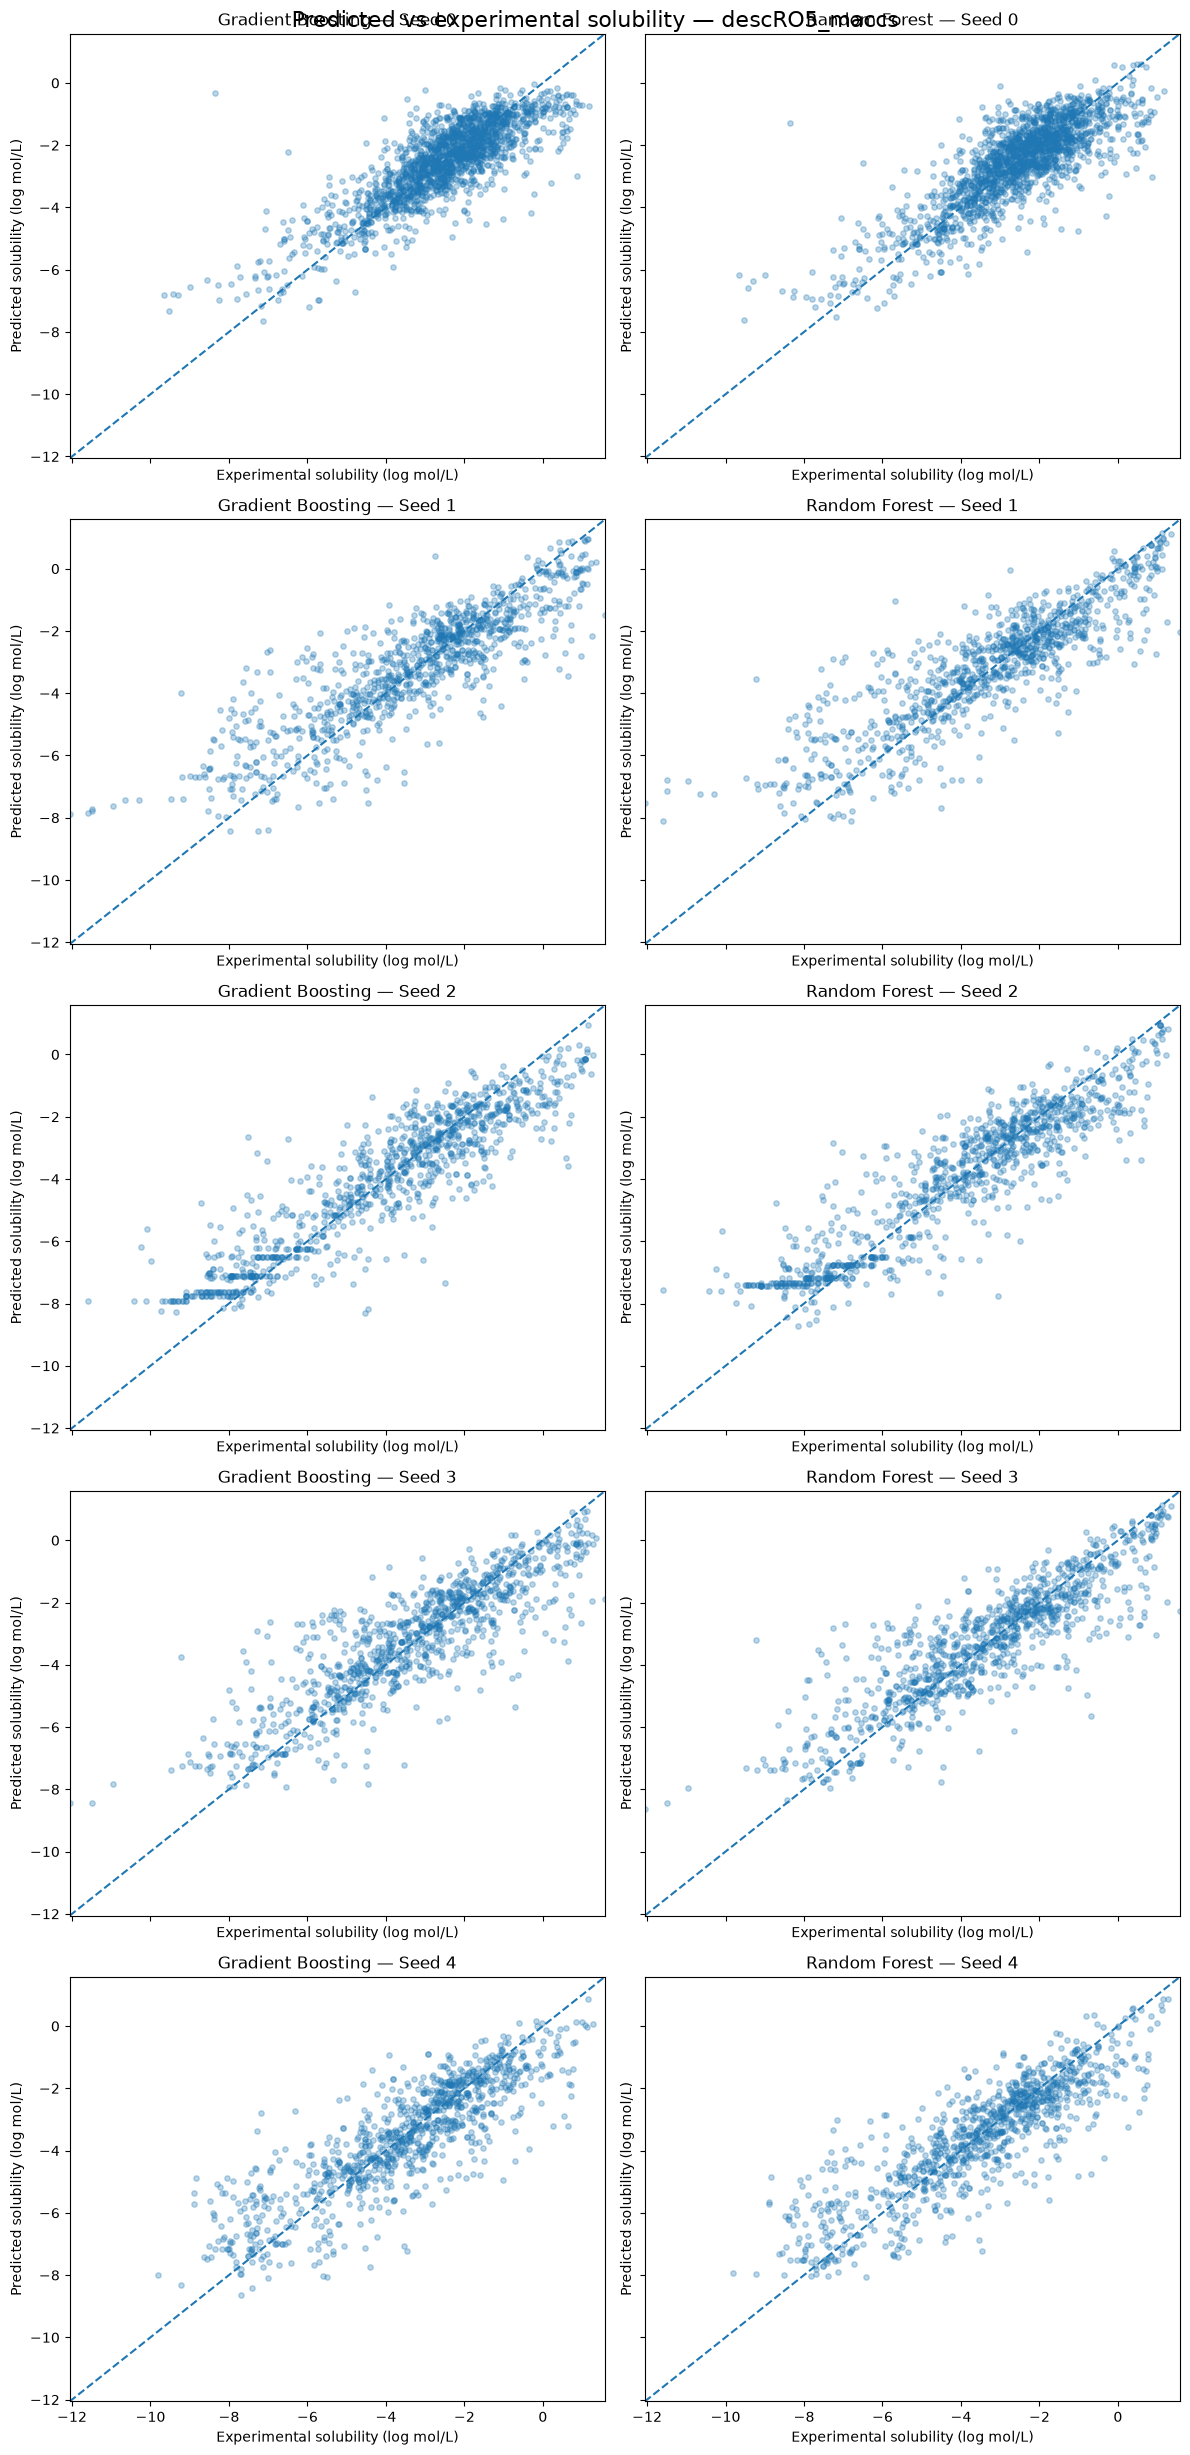

In [46]:
fig, axes = plt.subplots(
    nrows=len(SEEDS),
    ncols=len(MODELS),
    figsize=(12, 25),
    sharex=True,
    sharey=True,
)

for row, seed in enumerate(SEEDS):
    for col, model_name in enumerate(MODELS):

        ax = axes[row, col]

        subset = plot_predictions[
            (plot_predictions["seed"] == seed)
            & (plot_predictions["model"] == model_name)
        ]

        ax.scatter(
            subset["y_true"],
            subset["y_pred"],
            alpha=0.3,
            s=15,
        )

        # Perfect prediction reference
        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            linestyle="--",
        )

        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)

        model_title = (
            "Gradient Boosting"
            if model_name == "gradient_boosting"
            else "Random Forest"
        )

        ax.set_title(
            f"{model_title} — Seed {seed}"
        )

        ax.set_xlabel(
            "Experimental solubility (log mol/L)"
        )

        ax.set_ylabel(
            "Predicted solubility (log mol/L)"
        )

fig.suptitle(
    f"Predicted vs experimental solubility — {FEATURE_NAME}",
    fontsize=16,
)

plt.tight_layout()
plt.show()

**4. Residual analysis**


In [47]:
predictions["residual"] = (
    predictions["y_true"]
    - predictions["y_pred"]
)

predictions["absolute_error"] = (
    predictions["residual"].abs()
)

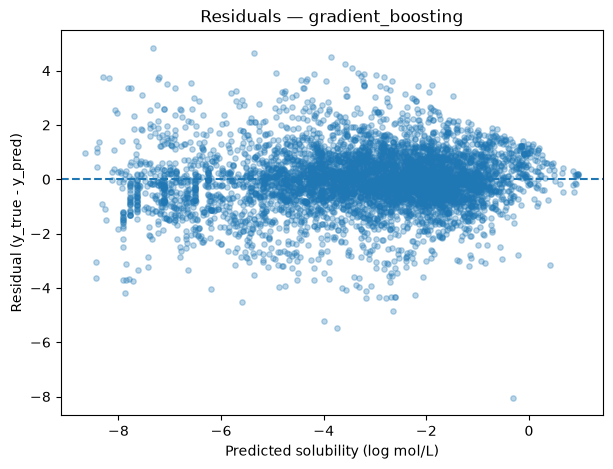

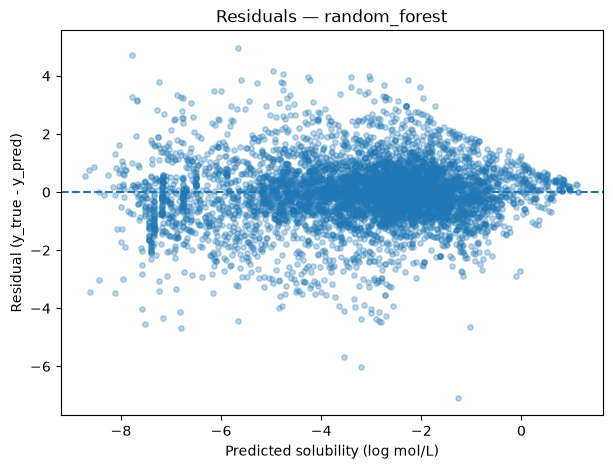

In [48]:
FEATURE_NAME = "descRO5_maccs"

for model_name in MODELS:
    subset = predictions[
        (predictions["features"] == FEATURE_NAME)
        & (predictions["model"] == model_name)
    ]

    plt.figure(figsize=(7, 5))

    plt.scatter(
        subset["y_pred"],
        subset["residual"],
        alpha=0.3,
        s=15,
    )

    plt.axhline(0, linestyle="--")

    plt.xlabel("Predicted solubility (log mol/L)")
    plt.ylabel("Residual (y_true - y_pred)")
    plt.title(f"Residuals — {model_name}")

    plt.show()

**5. Error across solubility ranges**


In [54]:
bins = [-float("inf"), -8, -6, -4, -2, 0, float("inf")]

predictions["solubility_bin"] = pd.cut(
    predictions["y_true"],
    bins=bins,
)

error_by_bin = (
    predictions[
        predictions["features"] == FEATURE_NAME
    ]
    .groupby(
        ["model", "solubility_bin"],
        observed=True,
    )
    .agg(
        n=("y_true", "size"),
        MAE=("absolute_error", "mean"),
        bias=("residual", "mean"),
    )
    .reset_index()
)

error_by_bin.sort_values(by="MAE", ascending=False)

,model,solubility_bin,n,MAE,bias
6,random_forest,"(-inf, -8.0]",178,1.874363,-1.867900
0,gradient_boosting,"(-inf, -8.0]",178,1.803108,-1.803108
5,gradient_boosting,"(0.0, inf]",305,1.335825,1.324850
11,random_forest,"(0.0, inf]",305,1.149492,1.132490
1,gradient_boosting,"(-8.0, -6.0]",548,1.106478,-0.977625
7,random_forest,"(-8.0, -6.0]",548,1.089771,-0.923580
2,gradient_boosting,"(-6.0, -4.0]",1058,0.811096,-0.389048
8,random_forest,"(-6.0, -4.0]",1058,0.791907,-0.335866
10,random_forest,"(-2.0, 0.0]",1448,0.729954,0.519167
4,gradient_boosting,"(-2.0, 0.0]",1448,0.720490,0.520449


**6. Worst prediction**


In [51]:
worst_predictions = (
    predictions[
        predictions["features"] == FEATURE_NAME
    ]
    .sort_values(
        "absolute_error",
        ascending=False,
    )
    .head(20)
)

worst_predictions[
    [
        "seed",
        "Drug",
        "model",
        "y_true",
        "y_pred",
        "absolute_error",
    ]
]

,seed,Drug,model,y_true,y_pred,absolute_error
791,0,O=S(=O)([O-])c1ccc(O)cc1.[Na+],gradient_boosting,-8.363189,-0.309124,8.054066
2544,0,O=S(=O)([O-])c1ccc(O)cc1.[Na+],random_forest,-8.363189,-1.273906,7.089283
24389,3,CCOC(=O)OCCOc1cc(O)c2c(c1N)C(=O)c1ccccc1C2=O,random_forest,-9.219530,-3.212869,6.006661
12401,1,CCOC(=O)OCCOc1cc(O)c2c(c1N)C(=O)c1ccccc1C2=O,random_forest,-9.219530,-3.536968,5.682562
23390,3,CCOC(=O)OCCOc1cc(O)c2c(c1N)C(=O)c1ccccc1C2=O,gradient_boosting,-9.219530,-3.744481,5.475049
11402,1,CCOC(=O)OCCOc1cc(O)c2c(c1N)C(=O)c1ccccc1C2=O,gradient_boosting,-9.219530,-3.985482,5.234048
23884,3,CCN(CC)c1ccc(C(c2ccc(N(CC)CC)cc2)c2c(S(=O)(=O)...,random_forest,-0.698476,-5.660150,4.961674
16935,2,COc1ccc(-c2cc(=O)c3c(O)cc(O[C@@H]4O[C@H](CO[C@...,gradient_boosting,-7.505542,-2.656869,4.848673
17446,2,C1=C\CC/C=C\CC/1.C1=C\CC/C=C\CC/1.[Cl].[Cl].[R...,gradient_boosting,-2.499798,-7.334838,4.835040
17517,2,Fc1ccc2c(c1)CC[C@@H]([C@@H]1CO1)O2.Fc1ccc2c(c1...,random_forest,-3.052101,-7.773252,4.721151


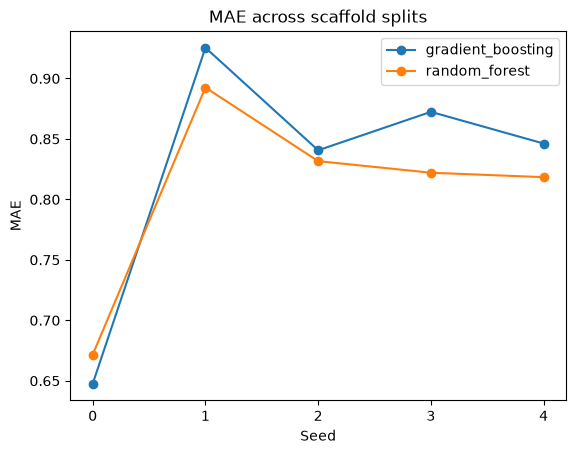

In [ ]:
mae_by_seed = metrics[
    metrics["features"] == FEATURE_NAME
]

for model_name in MODELS:
    subset = mae_by_seed[
        mae_by_seed["model"] == model_name
    ]

    plt.plot(
        subset["seed"],
        subset["MAE"],
        marker="o",
        label=model_name,
    )

plt.xticks(SEEDS)
plt.xlabel("Seed")
plt.ylabel("MAE")
plt.title("MAE across scaffold splits")
plt.legend()
plt.show()